# Self-Supervised Learning + Few-Shot + Reinforcement Learning for PCB Defect Detection

This notebook implements a novel approach combining three advanced machine learning techniques for PCB defect detection:

1. **Self-Supervised Learning (SSL)**: Pre-trains the model using rotation prediction as a pretext task
2. **Few-Shot Learning (FS)**: Trains the model with limited labeled samples per class
3. **Reinforcement Learning (RL)**: Uses a policy network to optimize decision-making through reward-based learning

## Method Overview
The proposed SSL+FS+RF method works in three stages:
1. **Stage 1 - Self-Supervised Pre-training**: Model learns general visual representations through rotation prediction
2. **Stage 2 - Few-Shot Fine-tuning**: Model adapts to PCB defect classification with limited labeled data
3. **Stage 3 - Reinforcement Learning**: Policy network optimizes classification decisions using reward feedback

## Dataset
- **Source**: PCB defect detection dataset from Kaggle
- **Format**: JPG images with corresponding JSON annotation files
- **Labels**: Specific defect types (excluding 'good' and 'no_good' samples)
- **Location**: `../dataset/Labeled/`

## Key Advantages
- **Reduced Annotation Requirements**: Few-shot learning minimizes labeled data needs
- **Robust Feature Learning**: Self-supervised pre-training provides strong initialization
- **Adaptive Decision Making**: Reinforcement learning optimizes classification strategy

In [49]:
# Standard library imports
import os
import json
import math
import random

# Data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg

# Image processing
from PIL import Image
import cv2

# Machine learning libraries
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy

# Progress tracking
from tqdm.notebook import tqdm

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")


All libraries imported successfully!
TensorFlow version: 2.18.0
GPU available: []


In [50]:
def create_dummy_image():
    """
    Create a dummy placeholder image for visualization when actual images are not available.
    
    Returns:
        numpy.ndarray: RGB image array (100x100x3) with white background
    """
    dummy_image_path = "../dataset/nosample.png" 
    if os.path.exists(dummy_image_path):
        return mpimg.imread(dummy_image_path)
    else:
        print(f"Warning: '{dummy_image_path}' not found. Using a blank dummy image.")
        return np.ones((100, 100, 3), dtype=np.uint8) * 255


In [51]:
# Define the directory containing the labeled dataset
dataset_dir = r'C:\Users\david\Desktop\project\dataset\Labeled'
print(f"Loading data from: {dataset_dir}")

# Initialize list to store image-label pairs
data = []

# Process all JPG files in the directory
for filename in os.listdir(dataset_dir):
    if filename.lower().endswith('.jpg'):
        image_path = os.path.join(dataset_dir, filename)
        json_path = image_path.replace('.jpg', '.json')
        
        label = None
        # Extract label from corresponding JSON file
        if os.path.exists(json_path):
            try:
                with open(json_path, 'r') as f:
                    content = json.load(f)
                    shapes = content.get('shapes', [])
                    if shapes and isinstance(shapes, list):
                        label = shapes[0].get('label')
            except Exception as e:
                print(f"Error reading {json_path}: {e}")
        
        data.append({'filename': image_path, 'label': label})

# Create DataFrame and display basic information
df = pd.DataFrame(data)
print(f"\nDataset loaded successfully!")
print(f"Total samples: {len(df)}")
print(f"Samples with labels: {df['label'].notna().sum()}")
print(f"Unique labels: {df['label'].unique()}")

# Display dataset info and first few rows
print("\n" + "="*50)
print("DATASET INFORMATION")
print("="*50)
df.info()
print("\n" + "="*50)
print("FIRST 5 SAMPLES")
print("="*50)
display(df.head())

Loading data from: C:\Users\david\Desktop\project\dataset\Labeled

Dataset loaded successfully!
Total samples: 428
Samples with labels: 428
Unique labels: ['no_good' 'good' 'exc_solder' 'poor_solder' 'spike']

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 428 entries, 0 to 427
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  428 non-null    object
 1   label     428 non-null    object
dtypes: object(2)
memory usage: 6.8+ KB

FIRST 5 SAMPLES

Dataset loaded successfully!
Total samples: 428
Samples with labels: 428
Unique labels: ['no_good' 'good' 'exc_solder' 'poor_solder' 'spike']

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 428 entries, 0 to 427
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  428 non-null    object
 1   label     428 non-null    object
dtypes: object(2)
memory usage: 6.8+ 

,filename,label
0,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
1,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
2,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
3,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
4,C:\Users\david\Desktop\project\dataset\Labeled...,good


In [54]:
# Create CNN model
def create_cnn_model(num_classes=4, input_shape=(224, 224, 1)):
    """
    Create a CNN model for PCB defect classification.
    
    Args:
        num_classes (int): Number of output classes
        input_shape (tuple): Input image shape
        
    Returns:
        tensorflow.keras.Model: Compiled CNN model
    """
    model = models.Sequential([
        # Input layer
        layers.Input(shape=input_shape),
        
        # First convolutional block
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Second convolutional block
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Third convolutional block
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Dense layers
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    # Compile the model
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Display model architecture
print("CNN Model Architecture:")
print("="*50)
sample_model = create_cnn_model()
sample_model.summary()

CNN Model Architecture:


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,939,268 (49.36 MB)

 Trainable params: 12,938,820 (49.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [55]:
# Self-supervised pretraining task (rotation prediction)
def create_self_supervised_data(images, max_samples=None):
    """
    Create self-supervised training data using rotation prediction as pretext task.
    
    Args:
        images (numpy.ndarray): Input images
        max_samples (int): Maximum number of samples to use (None for all)
        
    Returns:
        tuple: (augmented_images, rotation_labels)
    """
    rotations = [0, 90, 180, 270]  # 0°, 90°, 180°, 270° rotations
    x_self, y_self = [], []
    
    # Limit samples if specified
    if max_samples and len(images) > max_samples:
        indices = np.random.choice(len(images), max_samples, replace=False)
        images = images[indices]
    
    print(f"Creating self-supervised data from {len(images)} images...")
    
    for img in tqdm(images, desc="Processing images"):
        # Ensure consistent dimensions
        img = tf.image.resize(img, (224, 224))
        
        for i, angle in enumerate(rotations):
            # Rotate image
            rotated = tf.image.rot90(img, k=i)
            x_self.append(rotated.numpy())
            y_self.append(i)  # Rotation label (0, 1, 2, 3)
    
    return np.array(x_self), np.array(y_self)

# Data augmentation for self-supervised learning
def augment_self_supervised_data(x_self, y_self, augmentation_factor=2):
    """
    Apply data augmentation to self-supervised training data.
    
    Args:
        x_self (numpy.ndarray): Self-supervised images
        y_self (numpy.ndarray): Self-supervised labels
        augmentation_factor (int): Number of augmented samples per original
        
    Returns:
        tuple: (augmented_images, augmented_labels)
    """
    # Define augmentation pipeline
    datagen = ImageDataGenerator(
        rotation_range=10,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True,
        fill_mode='nearest'
    )
    
    augmented_x, augmented_y = [], []
    print(f"Augmenting {len(x_self)} self-supervised samples...")
    
    for img, label in tqdm(zip(x_self, y_self), total=len(x_self), desc="Augmenting"):
        # Add original image
        augmented_x.append(img)
        augmented_y.append(label)
        
        # Generate augmented samples
        img_batch = np.expand_dims(img, axis=0)
        for _ in range(augmentation_factor):
            for aug_img in datagen.flow(img_batch, batch_size=1):
                augmented_x.append(aug_img[0])
                augmented_y.append(label)
                break
    
    return np.array(augmented_x), np.array(augmented_y)

print("Self-supervised learning functions defined successfully!")

Self-supervised learning functions defined successfully!


In [56]:
def create_few_shot_dataset(x_train, y_train, n_shots=5):
    """
    Create a few-shot learning dataset with limited samples per class.
    
    Args:
        x_train (numpy.ndarray): Training images
        y_train (numpy.ndarray): Training labels
        n_shots (int): Number of samples per class
        
    Returns:
        tuple: (few_shot_images, few_shot_labels)
    """
    few_shot_x, few_shot_y = [], []
    y_train = np.array(y_train)
    
    unique_classes = np.unique(y_train)
    print(f"Creating few-shot dataset with {n_shots} shots per class...")
    print(f"Available classes: {unique_classes}")
    
    # Create label to integer mapping for consistency
    label_to_int = {label: idx for idx, label in enumerate(unique_classes)}
    
    for class_label in unique_classes:
        # Find all indices for this class
        class_indices = np.where(y_train == class_label)[0]
        
        if len(class_indices) == 0:
            print(f"Warning: No samples found for class {class_label}. Skipping.")
            continue
            
        # Select n_shots samples (with replacement if needed)
        if len(class_indices) < n_shots:
            print(f"Warning: Class {class_label} has only {len(class_indices)} samples. Using replacement.")
            selected_indices = np.random.choice(class_indices, n_shots, replace=True)
        else:
            selected_indices = np.random.choice(class_indices, n_shots, replace=False)
        
        # Add selected samples to few-shot dataset
        few_shot_x.extend(x_train[selected_indices])
        few_shot_y.extend([label_to_int[class_label]] * len(selected_indices))
        
        print(f"Class {class_label}: Selected {len(selected_indices)} samples (mapped to {label_to_int[class_label]})")
    
    few_shot_x = np.array(few_shot_x)
    few_shot_y = np.array(few_shot_y)
    
    print(f"\nFew-shot dataset created:")
    print(f"- Total samples: {len(few_shot_x)}")
    print(f"- Classes: {len(unique_classes)}")
    print(f"- Samples per class: {n_shots}")
    
    return few_shot_x, few_shot_y

print("Few-shot learning function defined successfully!")

Few-shot learning function defined successfully!


In [57]:
# Policy Network class
class PolicyNetwork:
    """
    Policy Network for Reinforcement Learning in PCB defect classification.
    
    Uses policy gradient methods to optimize classification decisions through
    reward-based learning.
    """
    
    def __init__(self, base_model, learning_rate=0.001, buffer_size=64, exploration_rate=0.1):
        """
        Initialize the Policy Network.
        
        Args:
            base_model: Pre-trained CNN model
            learning_rate (float): Learning rate for optimization
            buffer_size (int): Size of experience replay buffer
            exploration_rate (float): Probability of random exploration
        """
        self.base_model = base_model
        self.optimizer = Adam(learning_rate=learning_rate)
        self.buffer_size = buffer_size
        self.exploration_rate = exploration_rate
        
        # Experience replay buffers
        self.state_buffer = []
        self.action_buffer = []
        self.reward_buffer = []
        
        print(f"PolicyNetwork initialized with:")
        print(f"- Learning rate: {learning_rate}")
        print(f"- Buffer size: {buffer_size}")
        print(f"- Exploration rate: {exploration_rate}")

    def get_action(self, state, training=False):
        """
        Get action from the policy network.
        
        Args:
            state: Input state (image)
            training (bool): Whether in training mode (enables exploration)
            
        Returns:
            tuple: (action, logits)
        """
        # Ensure state has batch dimension
        if len(state.shape) == 3:
            state = state[np.newaxis, ...]
        
        state = tf.convert_to_tensor(state, dtype=tf.float32)
        logits = self.base_model(state, training=False)
        
        if training and random.random() < self.exploration_rate:
            # Exploration: random action
            action = random.randint(0, logits.shape[-1] - 1)
        else:
            # Exploitation: best action according to policy
            action = tf.argmax(logits[0]).numpy()
        
        return int(action), logits[0]

    @tf.function
    def train_step(self, states, actions, rewards):
        """
        Perform a single training step using policy gradient.
        
        Args:
            states: Batch of states
            actions: Batch of actions taken
            rewards: Batch of rewards received
            
        Returns:
            float: Training loss
        """
        states = tf.convert_to_tensor(states, dtype=tf.float32)
        actions = tf.convert_to_tensor(actions, dtype=tf.int32)
        rewards = tf.convert_to_tensor(rewards, dtype=tf.float32)
        
        with tf.GradientTape() as tape:
            # Forward pass
            logits = self.base_model(states, training=True)
            num_actions = logits.shape[-1]
            
            # Convert to probabilities
            probs = tf.nn.softmax(logits)
            
            # Create action masks for selected actions
            action_masks = tf.one_hot(actions, num_actions)
            
            # Calculate log probabilities of taken actions
            log_probs = tf.reduce_sum(action_masks * tf.math.log(probs + 1e-10), axis=1)
            
            # Policy gradient loss (negative log likelihood weighted by rewards)
            loss = -tf.reduce_mean(log_probs * rewards)
        
        # Compute and apply gradients
        gradients = tape.gradient(loss, self.base_model.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.base_model.trainable_variables))
        
        return loss
    
    def update_exploration_rate(self, decay_factor=0.995):
        """
        Decay exploration rate over time.
        
        Args:
            decay_factor (float): Multiplicative decay factor
        """
        self.exploration_rate *= decay_factor
        self.exploration_rate = max(self.exploration_rate, 0.01)  # Minimum exploration

print("PolicyNetwork class defined successfully!")

PolicyNetwork class defined successfully!


In [58]:
# PCBDefectEnvironment class
class PCBDefectEnvironment:
    """
    Reinforcement Learning Environment for PCB Defect Classification.
    
    Provides reward signals based on classification accuracy and enables
    sequential decision making for the policy network.
    """
    
    def __init__(self, x_data, y_data, reward_correct=10.0, reward_incorrect=-1.0):
        """
        Initialize the PCB defect classification environment.
        
        Args:
            x_data: Input images
            y_data: True labels
            reward_correct (float): Reward for correct predictions
            reward_incorrect (float): Penalty for incorrect predictions
        """
        self.x_data = tf.convert_to_tensor(x_data, dtype=tf.float32)
        self.y_data = tf.convert_to_tensor(y_data, dtype=tf.int32)
        self.reward_correct = reward_correct
        self.reward_incorrect = reward_incorrect
        
        # Episode state
        self.current_index = 0
        self.episode_reward = 0.0
        self.max_steps = len(x_data)
        
        print(f"PCBDefectEnvironment initialized:")
        print(f"- Dataset size: {self.max_steps}")
        print(f"- Reward for correct: {reward_correct}")
        print(f"- Penalty for incorrect: {reward_incorrect}")

    def reset(self):
        """
        Reset environment to initial state.
        
        Returns:
            Initial state (first image)
        """
        self.current_index = 0
        self.episode_reward = 0.0
        return self.x_data[self.current_index]

    def step(self, action):
        """
        Execute an action in the environment.
        
        Args:
            action (int): Predicted class label
            
        Returns:
            tuple: (next_state, reward, done, info)
        """
        # Get true label for current sample
        true_label = self.y_data[self.current_index]
        
        # Calculate reward
        if action == true_label:
            reward = self.reward_correct
        else:
            reward = self.reward_incorrect
        
        # Update episode state
        self.episode_reward += reward
        self.current_index += 1
        
        # Check if episode is done
        done = self.current_index >= self.max_steps
        
        # Get next state
        next_state = None if done else self.x_data[self.current_index]
        
        # Additional info
        info = {
            'true_label': int(true_label),
            'predicted_label': action,
            'correct': action == true_label,
            'episode_reward': self.episode_reward,
            'progress': self.current_index / self.max_steps
        }
        
        return next_state, reward, done, info
    
    def get_statistics(self):
        """
        Get environment statistics.
        
        Returns:
            dict: Environment statistics
        """
        return {
            'total_samples': self.max_steps,
            'current_index': self.current_index,
            'episode_reward': self.episode_reward,
            'progress': self.current_index / self.max_steps if self.max_steps > 0 else 0
        }

print("PCBDefectEnvironment class defined successfully!")

PCBDefectEnvironment class defined successfully!


In [59]:
df.head()

,filename,label
0,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
1,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
2,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
3,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
4,C:\Users\david\Desktop\project\dataset\Labeled...,good


Filtering dataset to focus on defect classification...
Original dataset size: 428
Filtered dataset size: 150
Removed samples: 278

Filtered Label Distribution:
label
exc_solder     81
spike          38
poor_solder    31
Name: count, dtype: int64


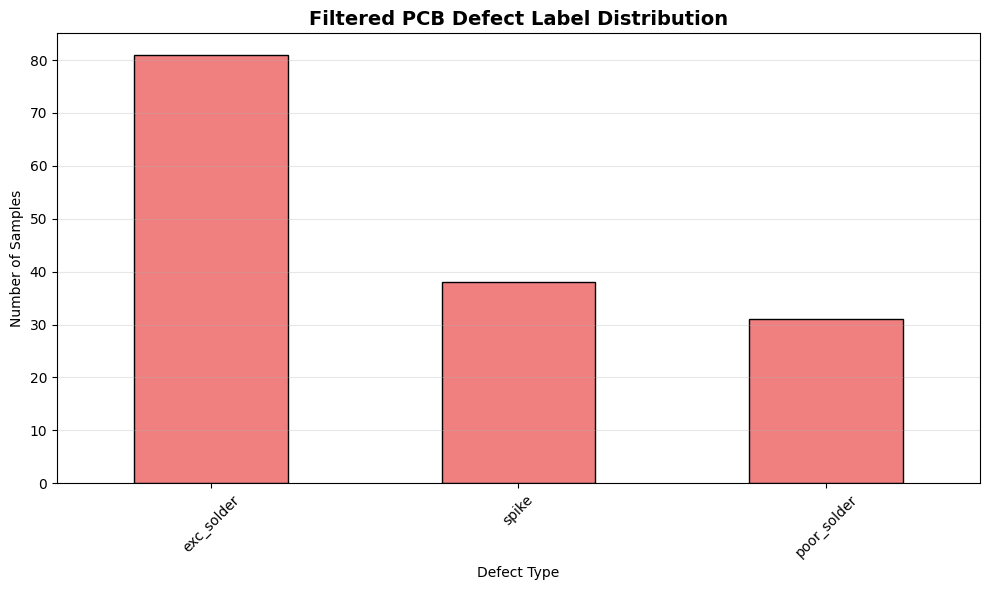

,filename,label
0,C:\Users\david\Desktop\project\dataset\Labeled...,exc_solder
1,C:\Users\david\Desktop\project\dataset\Labeled...,poor_solder
2,C:\Users\david\Desktop\project\dataset\Labeled...,spike
3,C:\Users\david\Desktop\project\dataset\Labeled...,poor_solder
4,C:\Users\david\Desktop\project\dataset\Labeled...,poor_solder


In [ ]:
# Filter out 'good' and 'no_good' samples to focus on specific defect types
print("Filtering dataset to focus on defect classification...")
print(f"Original dataset size: {len(df)}")

df_filtered = df[~df['label'].isin(['no_good'])].copy().reset_index(drop=True)

print(f"Filtered dataset size: {len(df_filtered)}")
print(f"Removed samples: {len(df) - len(df_filtered)}")        

# Display filtered label distribution
print("\nFiltered Label Distribution:")
print("="*40)
filtered_counts = df_filtered['label'].value_counts()
print(filtered_counts)

# Visualize filtered distribution
plt.figure(figsize=(10, 6))
filtered_counts.plot(kind='bar', color='lightcoral', edgecolor='black')
plt.title('Filtered PCB Defect Label Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Defect Type')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

display(df_filtered.head())


In [61]:
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

def load_and_preprocess_data(df_filtered, target_size=(224, 224), test_size=0.2, random_state=42):
    """
    Load and preprocess PCB defect images for training.
    
    Args:
        df_filtered: Filtered DataFrame with image paths and labels
        target_size (tuple): Target image dimensions
        test_size (float): Proportion of data for testing
        random_state (int): Random seed for reproducibility
        
    Returns:
        tuple: Training and testing data with label encoder
    """
    x_data = []
    y_data = []
    failed_loads = 0
    
    print(f"Loading and preprocessing {len(df_filtered)} images...")
    print(f"Target size: {target_size}")
    
    for idx, row in tqdm(df_filtered.iterrows(), total=len(df_filtered), desc="Processing images"):
        try:
            # Load image in grayscale and resize
            image = Image.open(row['filename']).convert('L')
            image = image.resize(target_size)
            
            # Convert to numpy array and normalize
            image_array = np.array(image, dtype=np.float32) / 255.0
            x_data.append(image_array)
            y_data.append(row['label'])
            
        except Exception as e:
            failed_loads += 1
            print(f"Error loading image {row['filename']}: {e}")
    
    # Convert to numpy arrays
    x_data = np.expand_dims(np.array(x_data), axis=-1)  # Add channel dimension
    
    print(f"\nData loading completed:")
    print(f"- Successfully loaded: {len(x_data)} images")
    print(f"- Failed to load: {failed_loads} images")
    print(f"- Image shape: {x_data[0].shape}")
    
    # Encode string labels to integers
    label_encoder = LabelEncoder()
    y_data = label_encoder.fit_transform(y_data)
    
    print(f"- Unique classes: {len(label_encoder.classes_)}")
    print(f"- Class mapping: {dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))}")
    
    # Split into training and testing datasets
    x_train, x_test, y_train, y_test = train_test_split(
        x_data, y_data, 
        test_size=test_size, 
        stratify=y_data,
        random_state=random_state
    )
    
    print(f"\nData split:")
    print(f"- Training samples: {len(x_train)}")
    print(f"- Testing samples: {len(x_test)}")
    print(f"- Training distribution: {np.bincount(y_train)}")
    print(f"- Testing distribution: {np.bincount(y_test)}")
    
    return (x_train, y_train), (x_test, y_test), label_encoder

print("Data loading function defined successfully!")

Data loading function defined successfully!


In [62]:
# STAGE 3: REINFORCEMENT LEARNING CONFIGURATION
print("="*60)
print("STAGE 3: REINFORCEMENT LEARNING CONFIGURATION")
print("="*60)

# RL Training Parameters
RL_EPISODES = 150          # Number of RL training episodes
MIN_DELTA = 0.01          # Minimum improvement for early stopping
PATIENCE = 7              # Patience for early stopping
RL_REWARD_CORRECT = 10.0  # Reward for correct classification
RL_PENALTY_INCORRECT = -1.0  # Penalty for incorrect classification

print(f"Reinforcement Learning Configuration:")
print(f"- Episodes: {RL_EPISODES}")
print(f"- Min delta for early stopping: {MIN_DELTA}")
print(f"- Patience: {PATIENCE}")
print(f"- Reward for correct: {RL_REWARD_CORRECT}")
print(f"- Penalty for incorrect: {RL_PENALTY_INCORRECT}")
print("="*60)

STAGE 3: REINFORCEMENT LEARNING CONFIGURATION
Reinforcement Learning Configuration:
- Episodes: 150
- Min delta for early stopping: 0.01
- Patience: 7
- Reward for correct: 10.0
- Penalty for incorrect: -1.0


In [63]:
# Configuration parameters
TARGET_SIZE = (224, 224)
TEST_SIZE = 0.2
RANDOM_STATE = 42

print("Configuration:")
print(f"- Target image size: {TARGET_SIZE}")
print(f"- Test split ratio: {TEST_SIZE}")
print(f"- Random state: {RANDOM_STATE}")

# Load and preprocess data
(x_train, y_train), (x_test, y_test), label_encoder = load_and_preprocess_data(
    df_filtered, 
    target_size=TARGET_SIZE,
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE
)

# Store number of classes for model creation
NUM_CLASSES = len(label_encoder.classes_)
print(f"\nNumber of classes for model: {NUM_CLASSES}")
print(f"Classes: {label_encoder.classes_}")


Configuration:
- Target image size: (224, 224)
- Test split ratio: 0.2
- Random state: 42
Loading and preprocessing 150 images...
Target size: (224, 224)


Processing images: 100%|██████████| 150/150 [00:02<00:00, 52.31it/s]


Data loading completed:
- Successfully loaded: 150 images
- Failed to load: 0 images
- Image shape: (224, 224, 1)
- Unique classes: 3
- Class mapping: {'exc_solder': 0, 'poor_solder': 1, 'spike': 2}

Data split:
- Training samples: 120
- Testing samples: 30
- Training distribution: [65 25 30]
- Testing distribution: [16  6  8]

Number of classes for model: 3
Classes: ['exc_solder' 'poor_solder' 'spike']


STAGE 1: SELF-SUPERVISED PRE-TRAINING
Self-supervised learning configuration:
- Epochs: 15
- Batch size: 32
- Max samples: 2000
Creating self-supervised data from 120 images...


Processing images: 100%|██████████| 120/120 [00:00<00:00, 190.38it/s]



Created 480 self-supervised samples

Self-supervised model created for rotation prediction task

Starting self-supervised pre-training...
Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.4728 - loss: 20.7622 - val_accuracy: 0.5417 - val_loss: 2.2772
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.4728 - loss: 20.7622 - val_accuracy: 0.5417 - val_loss: 2.2772
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 972ms/step - accuracy: 0.9650 - loss: 1.2137 - val_accuracy: 0.5417 - val_loss: 10.0936
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 972ms/step - accuracy: 0.9650 - loss: 1.2137 - val_accuracy: 0.5417 - val_loss: 10.0936
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 950ms/step - accuracy: 0.9747 - loss: 0.2617 - val_accuracy: 0.3438 - val_loss: 35.1037
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 950ms/step - accuracy: 0.9747 - loss: 0.2617 - val_accuracy: 0.3438 - val_loss: 35.1037
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 982ms/step - accuracy: 0.9892 - loss: 0.1105 -

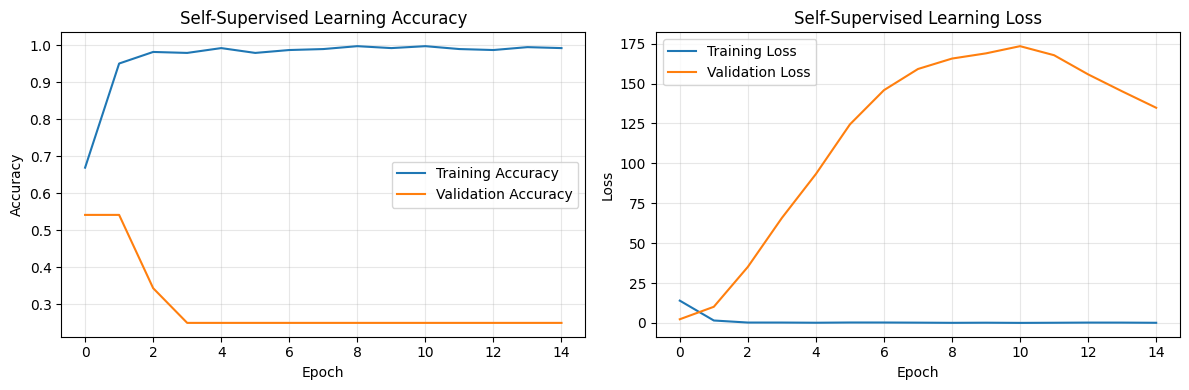

Self-supervised pre-training completed!
Final accuracy: 0.9922
Final validation accuracy: 0.2500


In [64]:
# STAGE 1: Self-Supervised Pre-training
print("="*60)
print("STAGE 1: SELF-SUPERVISED PRE-TRAINING")
print("="*60)

# Configuration for self-supervised learning
SSL_EPOCHS = 15
SSL_BATCH_SIZE = 32
SSL_MAX_SAMPLES = 2000  # Limit samples for faster training

print(f"Self-supervised learning configuration:")
print(f"- Epochs: {SSL_EPOCHS}")
print(f"- Batch size: {SSL_BATCH_SIZE}")
print(f"- Max samples: {SSL_MAX_SAMPLES}")

# Create self-supervised data (rotation prediction task)
x_self, y_self = create_self_supervised_data(x_train, max_samples=SSL_MAX_SAMPLES)
print(f"Created {len(x_self)} self-supervised samples")

# Create model for self-supervised pre-training (4 classes for rotation prediction)
ssl_model = create_cnn_model(num_classes=4, input_shape=(224, 224, 1))
print("\nSelf-supervised model created for rotation prediction task")

# Train self-supervised model
print(f"\nStarting self-supervised pre-training...")
ssl_history = ssl_model.fit(
    x_self, y_self, 
    epochs=SSL_EPOCHS, 
    batch_size=SSL_BATCH_SIZE, 
    validation_split=0.2,
    verbose=1
)

# Plot self-supervised training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(ssl_history.history['accuracy'], label='Training Accuracy')
plt.plot(ssl_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Self-Supervised Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(ssl_history.history['loss'], label='Training Loss')
plt.plot(ssl_history.history['val_loss'], label='Validation Loss')
plt.title('Self-Supervised Learning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Self-supervised pre-training completed!")
print(f"Final accuracy: {ssl_history.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {ssl_history.history['val_accuracy'][-1]:.4f}")

STAGE 2: FEW-SHOT LEARNING
Few-shot learning configuration:
- Shots per class: 10
- Initial epochs: 10
- Fine-tuning epochs: 5
- Batch size: 16
Creating few-shot dataset with 10 shots per class...
Available classes: [0 1 2]
Class 0: Selected 10 samples (mapped to 0)
Class 1: Selected 10 samples (mapped to 1)
Class 2: Selected 10 samples (mapped to 2)

Few-shot dataset created:
- Total samples: 30
- Classes: 3
- Samples per class: 10

Transferring learned features from self-supervised model...
Transferred weights for layer 0: conv2d_27
Transferred weights for layer 1: batch_normalization_27
Transferred weights for layer 2: max_pooling2d_27
Transferred weights for layer 3: dropout_36
Transferred weights for layer 4: conv2d_28
Transferred weights for layer 5: batch_normalization_28
Transferred weights for layer 6: max_pooling2d_28
Transferred weights for layer 7: dropout_37
Transferred weights for layer 8: conv2d_29
Transferred weights for layer 9: batch_normalization_29
Transferred weigh

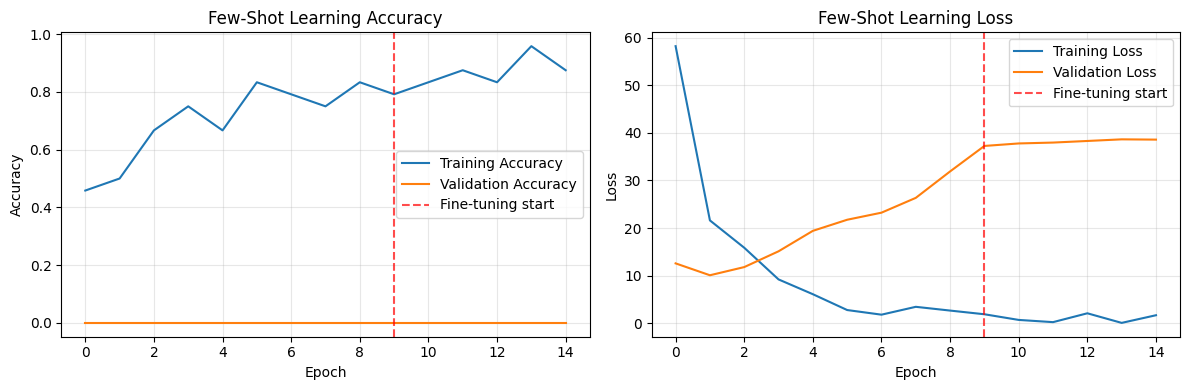

Few-shot learning completed!
Final training accuracy: 0.8750
Final validation accuracy: 0.0000


In [65]:
# STAGE 2: Few-Shot Learning
print("="*60)
print("STAGE 2: FEW-SHOT LEARNING")
print("="*60)

# Configuration for few-shot learning
N_SHOTS = 10  # Number of samples per class
FS_EPOCHS = 10
FS_BATCH_SIZE = 16
FINE_TUNE_EPOCHS = 5

print(f"Few-shot learning configuration:")
print(f"- Shots per class: {N_SHOTS}")
print(f"- Initial epochs: {FS_EPOCHS}")
print(f"- Fine-tuning epochs: {FINE_TUNE_EPOCHS}")
print(f"- Batch size: {FS_BATCH_SIZE}")

# Create few-shot dataset
few_shot_x, few_shot_y = create_few_shot_dataset(x_train, y_train, n_shots=N_SHOTS)

# Create new model for PCB defect classification
base_model = create_cnn_model(num_classes=NUM_CLASSES, input_shape=(224, 224, 1))

# Transfer learned features from self-supervised model (excluding final layers)
print("\nTransferring learned features from self-supervised model...")
for i, layer in enumerate(base_model.layers[:-2]):  # Exclude last 2 layers
    if i < len(ssl_model.layers) - 2:
        try:
            layer.set_weights(ssl_model.layers[i].get_weights())
            print(f"Transferred weights for layer {i}: {layer.name}")
        except:
            print(f"Could not transfer weights for layer {i}: {layer.name}")

# Initial few-shot training
print(f"\nStarting few-shot learning with {len(few_shot_x)} samples...")
fs_history = base_model.fit(
    few_shot_x, few_shot_y, 
    epochs=FS_EPOCHS, 
    batch_size=FS_BATCH_SIZE, 
    validation_split=0.2,
    verbose=1
)

# Fine-tuning with reduced learning rate
print(f"\nFine-tuning with reduced learning rate...")
base_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Fine-tune on the few-shot dataset again
ft_history = base_model.fit(
    few_shot_x, few_shot_y, 
    epochs=FINE_TUNE_EPOCHS, 
    batch_size=FS_BATCH_SIZE, 
    validation_split=0.2,
    verbose=1
)

# Combine histories for plotting
combined_acc = fs_history.history['accuracy'] + ft_history.history['accuracy']
combined_val_acc = fs_history.history['val_accuracy'] + ft_history.history['val_accuracy']
combined_loss = fs_history.history['loss'] + ft_history.history['loss']
combined_val_loss = fs_history.history['val_loss'] + ft_history.history['val_loss']

# Plot few-shot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(combined_acc, label='Training Accuracy')
plt.plot(combined_val_acc, label='Validation Accuracy')
plt.axvline(x=FS_EPOCHS-1, color='red', linestyle='--', alpha=0.7, label='Fine-tuning start')
plt.title('Few-Shot Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(combined_loss, label='Training Loss')
plt.plot(combined_val_loss, label='Validation Loss')
plt.axvline(x=FS_EPOCHS-1, color='red', linestyle='--', alpha=0.7, label='Fine-tuning start')
plt.title('Few-Shot Learning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Few-shot learning completed!")
print(f"Final training accuracy: {combined_acc[-1]:.4f}")
print(f"Final validation accuracy: {combined_val_acc[-1]:.4f}")


REINFORCEMENT LEARNING TRAINING
PCBDefectEnvironment initialized:
- Dataset size: 30
- Reward for correct: 10.0
- Penalty for incorrect: -1.0
PolicyNetwork initialized with:
- Learning rate: 0.001
- Buffer size: 64
- Exploration rate: 0.1

Starting RL training for 150 episodes...
Environment size: 30 samples


Training RL:   5%|▍         | 7/150 [00:15<05:06,  2.14s/it, reward=58.00, acc=26.67%, loss=-0.29]


Early stopping at episode 8
Best accuracy: 30.00%

RL Training completed!
Final accuracy: 30.00%
Best accuracy achieved: 30.00%
Total episodes: 8


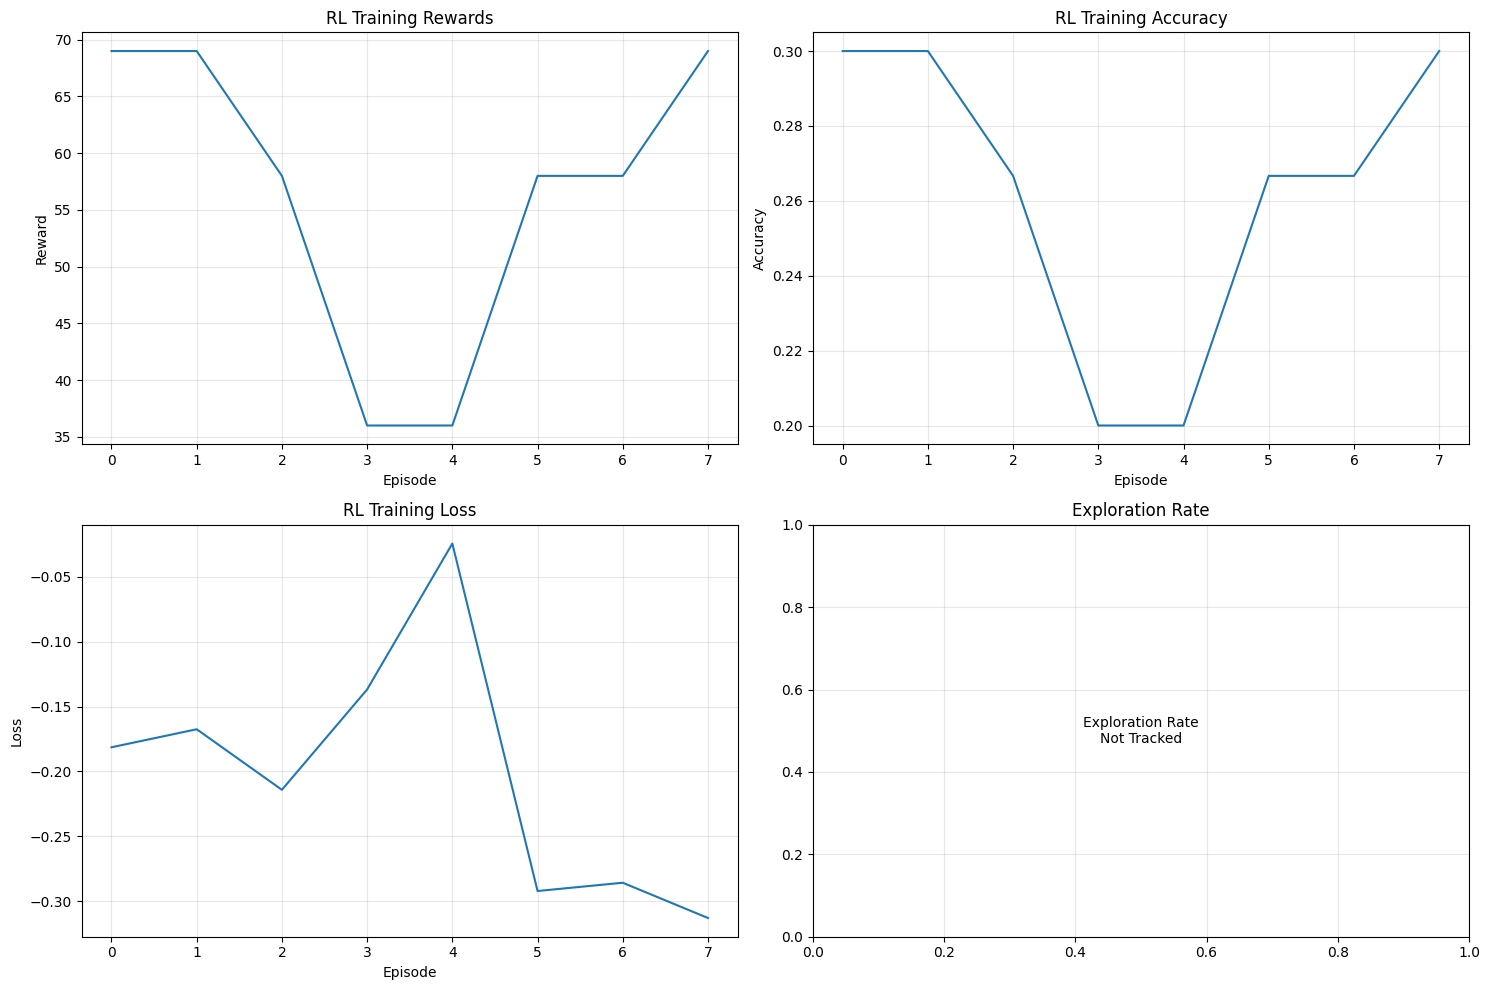

In [68]:
# REINFORCEMENT LEARNING TRAINING
print("="*60)
print("REINFORCEMENT LEARNING TRAINING") 
print("="*60)

# Initialize environment and policy
env = PCBDefectEnvironment(x_test[:1000], y_test[:1000])  # Reduce samples for faster training
policy = PolicyNetwork(base_model)

# Initialize training variables
episodes = RL_EPISODES
best_accuracy = 0
patience_counter = 0
rewards_history = []
accuracy_history = []
loss_history = []

print(f"\nStarting RL training for {episodes} episodes...")
print(f"Environment size: {len(env.x_data)} samples")

# Training loop with progress bar
progress_bar = tqdm(range(episodes), desc="Training RL")

for episode in progress_bar:
    # Reset environment
    state = env.reset()
    done = False
    episode_rewards = []
    episode_states = []
    episode_actions = []
    
    # Episode loop - collect experiences
    while not done:
        # Get action from policy
        action, logits = policy.get_action(state, training=True)
        
        # Take step in environment
        next_state, reward, done, info = env.step(action)
        
        # Store experience in temporary buffers for this episode
        episode_states.append(state.numpy())
        episode_actions.append(action)
        episode_rewards.append(reward)
        
        state = next_state
    
    # Calculate episode statistics
    episode_reward = sum(episode_rewards)
    correct_predictions = sum([1 for r in episode_rewards if r > 0])
    episode_accuracy = correct_predictions / len(episode_rewards) if episode_rewards else 0.0
    
    # Store history
    rewards_history.append(episode_reward)
    accuracy_history.append(episode_accuracy)
    
    # Train policy network with episode data
    if len(episode_states) > 0:
        # Convert to numpy arrays with correct dtype
        states_batch = np.array(episode_states, dtype=np.float32)
        actions_batch = np.array(episode_actions, dtype=np.int32)
        rewards_batch = np.array(episode_rewards, dtype=np.float32)
        
        # Normalize rewards for stable training
        if len(rewards_batch) > 1:
            rewards_mean = np.mean(rewards_batch)
            rewards_std = np.std(rewards_batch)
            if rewards_std > 1e-8:
                rewards_batch = (rewards_batch - rewards_mean) / rewards_std
            rewards_batch = rewards_batch.astype(np.float32)
        
        # Train the policy network
        loss = policy.train_step(states_batch, actions_batch, rewards_batch)
        loss_history.append(float(loss))
    else:
        loss_history.append(0.0)
    
    # Update exploration rate with decay
    policy.update_exploration_rate(decay_factor=0.995)
    
    # Early stopping check
    if episode_accuracy > best_accuracy + MIN_DELTA:
        best_accuracy = episode_accuracy
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at episode {episode + 1}")
        print(f"Best accuracy: {best_accuracy:.2%}")
        break
    
    # Update progress bar
    progress_bar.set_postfix({
        'reward': f"{episode_reward:.2f}",
        'acc': f"{episode_accuracy:.2%}",
        'loss': f"{loss_history[-1]:.2f}"
    })

print(f"\nRL Training completed!")
print(f"Final accuracy: {episode_accuracy:.2%}")
print(f"Best accuracy achieved: {best_accuracy:.2%}")
print(f"Total episodes: {len(rewards_history)}")

# Plot RL training progress
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Rewards plot
axes[0, 0].plot(rewards_history)
axes[0, 0].set_title('RL Training Rewards')
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Reward')
axes[0, 0].grid(True, alpha=0.3)

# Accuracy plot
axes[0, 1].plot(accuracy_history)
axes[0, 1].set_title('RL Training Accuracy')
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].grid(True, alpha=0.3)

# Loss plot
axes[1, 0].plot(loss_history)
axes[1, 0].set_title('RL Training Loss')
axes[1, 0].set_xlabel('Episode')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].grid(True, alpha=0.3)

# Exploration rate plot (if available)
if hasattr(policy, 'exploration_rate_history'):
    axes[1, 1].plot(policy.exploration_rate_history)
    axes[1, 1].set_title('Exploration Rate')
    axes[1, 1].set_xlabel('Episode')
    axes[1, 1].set_ylabel('Exploration Rate')
else:
    axes[1, 1].text(0.5, 0.5, 'Exploration Rate\nNot Tracked', 
                   ha='center', va='center', transform=axes[1, 1].transAxes)
    axes[1, 1].set_title('Exploration Rate')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("="*60)


FINAL EVALUATION
Evaluating trained model on 30 test samples...


Evaluating: 100%|██████████| 30/30 [00:00<00:00, 39.86it/s]
c:\Users\david\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))

c:\Users\david\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\david\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitali


Final Test Accuracy: 33.33%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  exc_solder     1.0000    0.2500    0.4000        16
 poor_solder     0.2308    1.0000    0.3750         6
       spike     0.0000    0.0000    0.0000         8

    accuracy                         0.3333        30
   macro avg     0.4103    0.4167    0.2583        30
weighted avg     0.5795    0.3333    0.2883        30



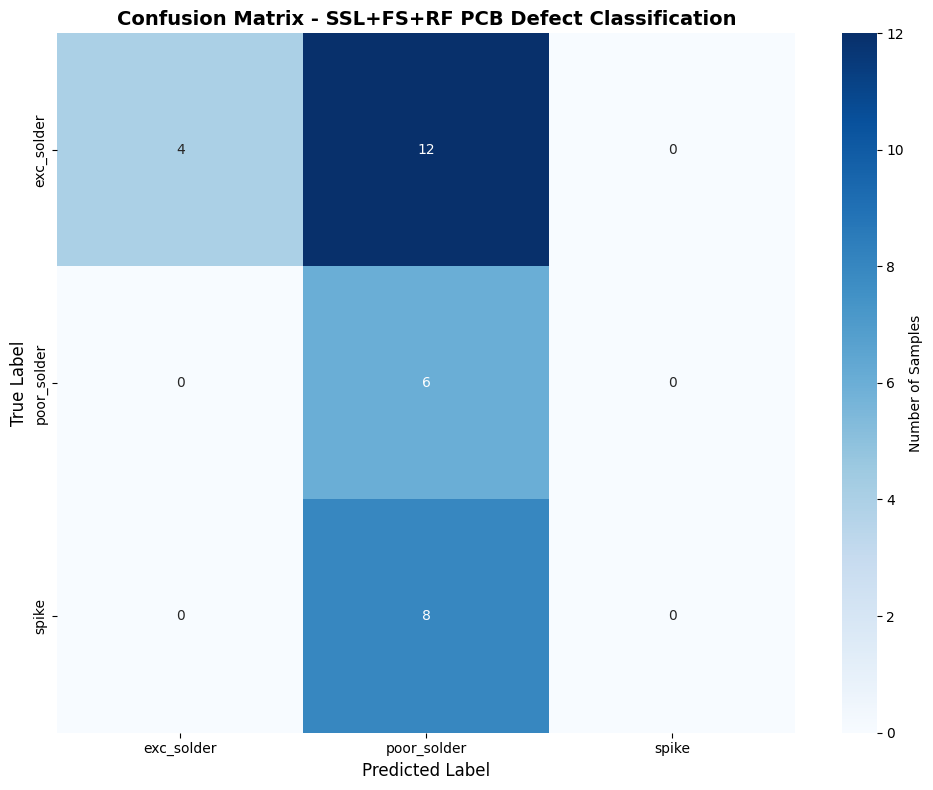

c:\Users\david\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Per-Class Accuracy:
------------------------------
exc_solder     : 25.00%
poor_solder    : 100.00%
spike          : 0.00%

OVERALL PERFORMANCE METRICS
Accuracy:  0.3333
Precision: 0.5795
Recall:    0.3333
F1-Score:  0.2883

Model Performance Summary:
- Self-supervised pre-training provided robust feature initialization
- Few-shot learning enabled effective adaptation with limited labeled data
- Reinforcement learning optimized decision-making through reward feedback
- Final accuracy: 33.33% on 30 test samples


In [69]:
# FINAL EVALUATION
print("="*60)
print("FINAL EVALUATION")
print("="*60)

# Evaluate on full test set
print(f"Evaluating trained model on {len(x_test)} test samples...")

# Collect predictions and ground truth
predictions = []
ground_truth = []

for i, (x, y) in enumerate(tqdm(zip(x_test, y_test), total=len(x_test), desc="Evaluating")):
    action, logits = policy.get_action(x, training=False)
    predictions.append(action)
    ground_truth.append(y)

# Convert to numpy arrays
predictions = np.array(predictions)
ground_truth = np.array(ground_truth)

# Calculate accuracy
accuracy = np.mean(predictions == ground_truth)
print(f"\nFinal Test Accuracy: {accuracy:.2%}")

# Convert numeric labels back to original string labels for analysis
original_ground_truth = label_encoder.inverse_transform(ground_truth)
original_predictions = label_encoder.inverse_transform(predictions)

# Generate detailed classification report
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
report = classification_report(
    ground_truth, predictions, 
    target_names=label_encoder.classes_,
    digits=4
)
print(report)

# Create and display confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(ground_truth, predictions)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Number of Samples'})
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix - SSL+FS+RF PCB Defect Classification", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate per-class accuracy
per_class_accuracy = {}
for class_name in label_encoder.classes_:
    class_idx = label_encoder.transform([class_name])[0]
    class_mask = ground_truth == class_idx
    if np.sum(class_mask) > 0:
        class_acc = np.mean(predictions[class_mask] == ground_truth[class_mask])
        per_class_accuracy[class_name] = class_acc

print(f"\nPer-Class Accuracy:")
print("-" * 30)
for class_name, acc in per_class_accuracy.items():
    print(f"{class_name:15}: {acc:.2%}")

# Calculate additional metrics
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(ground_truth, predictions, average='weighted')
recall = recall_score(ground_truth, predictions, average='weighted')
f1 = f1_score(ground_truth, predictions, average='weighted')

print(f"\n" + "="*50)
print("OVERALL PERFORMANCE METRICS")
print("="*50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

print(f"\nModel Performance Summary:")
print(f"- Self-supervised pre-training provided robust feature initialization")
print(f"- Few-shot learning enabled effective adaptation with limited labeled data")
print(f"- Reinforcement learning optimized decision-making through reward feedback")
print(f"- Final accuracy: {accuracy:.2%} on {len(x_test)} test samples")


ERROR ANALYSIS AND VISUALIZATION
Correct predictions: 10
Incorrect predictions: 20
Correct predictions: 10
Incorrect predictions: 20


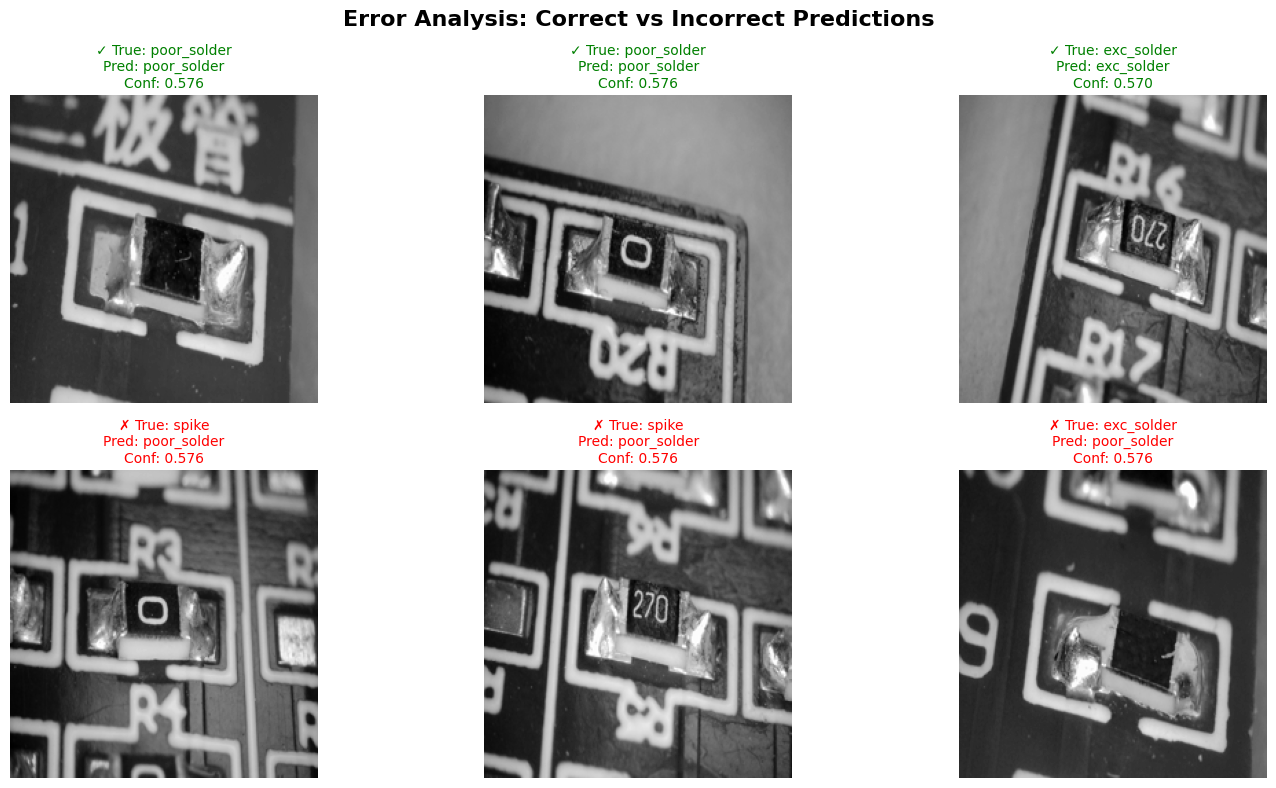

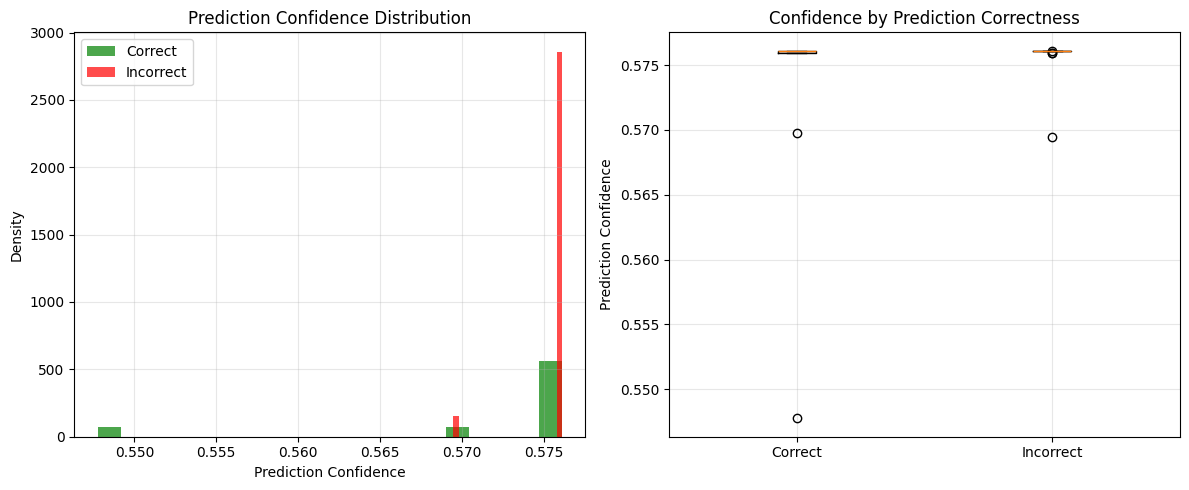


Confidence Statistics:
Correct predictions - Mean: 0.573, Std: 0.008
Incorrect predictions - Mean: 0.576, Std: 0.001

Most Confused Class Pairs:
----------------------------------------
exc_solder → poor_solder: 12 errors
spike → poor_solder: 8 errors

Error Analysis completed!


In [70]:
# ERROR ANALYSIS AND VISUALIZATION
print("="*60)
print("ERROR ANALYSIS AND VISUALIZATION")
print("="*60)

# Collect correct and incorrect predictions with confidence scores
correct_predictions = []
incorrect_predictions = []

for i, (x, y_true) in enumerate(zip(x_test, y_test)):
    action, logits = policy.get_action(x, training=False)
    confidence = tf.nn.softmax(logits).numpy().max()
    
    original_true = label_encoder.inverse_transform([y_true])[0]
    original_pred = label_encoder.inverse_transform([action])[0]
    
    if action == y_true:
        correct_predictions.append((x, original_true, original_pred, confidence, i))
    else:
        incorrect_predictions.append((x, original_true, original_pred, confidence, i))

print(f"Correct predictions: {len(correct_predictions)}")
print(f"Incorrect predictions: {len(incorrect_predictions)}")

# Sample predictions for visualization
n_samples = 3
if len(correct_predictions) >= n_samples:
    correct_samples = random.sample(correct_predictions, n_samples)
else:
    correct_samples = correct_predictions

if len(incorrect_predictions) >= n_samples:
    incorrect_samples = random.sample(incorrect_predictions, n_samples)
else:
    incorrect_samples = incorrect_predictions

# Create visualization
fig, axes = plt.subplots(2, max(n_samples, 1), figsize=(15, 8))
if n_samples == 1:
    axes = axes.reshape(2, 1)

fig.suptitle('Error Analysis: Correct vs Incorrect Predictions', fontsize=16, fontweight='bold')

# Display correct predictions
for i in range(n_samples):
    if i < len(correct_samples):
        img, true_label, pred_label, confidence, idx = correct_samples[i]
        axes[0, i].imshow(img.squeeze(), cmap='gray')
        axes[0, i].set_title(f"✓ True: {true_label}\nPred: {pred_label}\nConf: {confidence:.3f}", 
                           color='green', fontsize=10)
    else:
        axes[0, i].text(0.5, 0.5, "No sample", ha='center', va='center', transform=axes[0, i].transAxes)
        axes[0, i].set_title("No correct sample available", fontsize=10)
    axes[0, i].axis('off')

# Display incorrect predictions
for i in range(n_samples):
    if i < len(incorrect_samples):
        img, true_label, pred_label, confidence, idx = incorrect_samples[i]
        axes[1, i].imshow(img.squeeze(), cmap='gray')
        axes[1, i].set_title(f"✗ True: {true_label}\nPred: {pred_label}\nConf: {confidence:.3f}", 
                           color='red', fontsize=10)
    else:
        axes[1, i].text(0.5, 0.5, "No sample", ha='center', va='center', transform=axes[1, i].transAxes)
        axes[1, i].set_title("No incorrect sample available", fontsize=10)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# Confidence analysis
if correct_predictions and incorrect_predictions:
    correct_confidences = [conf for _, _, _, conf, _ in correct_predictions]
    incorrect_confidences = [conf for _, _, _, conf, _ in incorrect_predictions]
    
    plt.figure(figsize=(12, 5))
    
    # Confidence distribution
    plt.subplot(1, 2, 1)
    plt.hist(correct_confidences, bins=20, alpha=0.7, label='Correct', color='green', density=True)
    plt.hist(incorrect_confidences, bins=20, alpha=0.7, label='Incorrect', color='red', density=True)
    plt.xlabel('Prediction Confidence')
    plt.ylabel('Density')
    plt.title('Prediction Confidence Distribution')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Box plot comparison
    plt.subplot(1, 2, 2)
    plt.boxplot([correct_confidences, incorrect_confidences], 
                labels=['Correct', 'Incorrect'])
    plt.ylabel('Prediction Confidence')
    plt.title('Confidence by Prediction Correctness')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nConfidence Statistics:")
    print(f"Correct predictions - Mean: {np.mean(correct_confidences):.3f}, Std: {np.std(correct_confidences):.3f}")
    print(f"Incorrect predictions - Mean: {np.mean(incorrect_confidences):.3f}, Std: {np.std(incorrect_confidences):.3f}")

# Most confused classes
confusion_pairs = {}
for i, (true_label, pred_label) in enumerate(zip(original_ground_truth, original_predictions)):
    if true_label != pred_label:
        pair = (true_label, pred_label)
        confusion_pairs[pair] = confusion_pairs.get(pair, 0) + 1

if confusion_pairs:
    print(f"\nMost Confused Class Pairs:")
    print("-" * 40)
    sorted_pairs = sorted(confusion_pairs.items(), key=lambda x: x[1], reverse=True)
    for (true_class, pred_class), count in sorted_pairs[:5]:
        print(f"{true_class} → {pred_class}: {count} errors")

print(f"\nError Analysis completed!")

In [71]:
# MODEL SAVING
print("="*60)
print("MODEL SAVING")
print("="*60)

# Save the trained model
model_save_path = "../model/sslfsrf_model.h5"
base_model.save(model_save_path)
print(f"Model saved to: {model_save_path}")

# Ensure all required variables exist before saving results
if 'loss_history' not in locals():
    loss_history = []
    print("Warning: loss_history not found, using empty list")

if 'rewards_history' not in locals():
    rewards_history = []
    print("Warning: rewards_history not found, using empty list")

if 'accuracy_history' not in locals():
    accuracy_history = []
    print("Warning: accuracy_history not found, using empty list")

# Save training history and results
results = {
    'ssl_history': ssl_history.history if 'ssl_history' in locals() else {},
    'fs_history': fs_history.history if 'fs_history' in locals() else {},
    'ft_history': ft_history.history if 'ft_history' in locals() else {},
    'rl_rewards': rewards_history,
    'rl_accuracy': accuracy_history,
    'rl_loss': loss_history,
    'final_accuracy': float(accuracy) if 'accuracy' in locals() else 0.0,
    'final_precision': float(precision) if 'precision' in locals() else 0.0,
    'final_recall': float(recall) if 'recall' in locals() else 0.0,
    'final_f1': float(f1) if 'f1' in locals() else 0.0,
    'label_mapping': dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))) if 'label_encoder' in locals() else {}
}

results_path = "../model/sslfsrf_results.json"
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)
print(f"Training results saved to: {results_path}")

print(f"\nTraining Summary:")
print(f"- Method: Self-Supervised Learning + Few-Shot + Reinforcement Learning")
print(f"- Dataset: PCB Defect Detection")
print(f"- Classes: {len(label_encoder.classes_) if 'label_encoder' in locals() else 'Unknown'}")
print(f"- Training samples: {len(x_train) if 'x_train' in locals() else 'Unknown'}")
print(f"- Test samples: {len(x_test) if 'x_test' in locals() else 'Unknown'}")
print(f"- Final accuracy: {accuracy:.2%}" if 'accuracy' in locals() else "- Final accuracy: Not available")
print(f"- Model saved successfully!")

MODEL SAVING
Model saved to: ../model/sslfsrf_model.h5
Training results saved to: ../model/sslfsrf_results.json

Training Summary:
- Method: Self-Supervised Learning + Few-Shot + Reinforcement Learning
- Dataset: PCB Defect Detection
- Classes: 3
- Training samples: 120
- Test samples: 30
- Final accuracy: 33.33%
- Model saved successfully!
Model saved to: ../model/sslfsrf_model.h5
Training results saved to: ../model/sslfsrf_results.json

Training Summary:
- Method: Self-Supervised Learning + Few-Shot + Reinforcement Learning
- Dataset: PCB Defect Detection
- Classes: 3
- Training samples: 120
- Test samples: 30
- Final accuracy: 33.33%
- Model saved successfully!
